In [1]:
from utils import*

In [ ]:
# DS average
a_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
abe_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBacEuk_recovered.csv'

xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict(e_path)
print(len(xgroup2ds_e))
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))
xgroup2ds_abe = csv2dict(abe_path)
print(len(xgroup2ds_abe))

In [53]:
# new results

# NONE 1000 runs
df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_folditer_NONE.csv', index_col=0)
# preATP 1000 runs
# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)

In [ ]:
run2iter2ds = {}
for run in df_folds_folditer.columns:
    iter2ds = {}
    for x, i in df_folds_folditer[run].items():
        if x not in ['fold_independent', 'spontaneous']:
            if i not in iter2ds:
                iter2ds[i] = [x2ds[x]]
            else:
                iter2ds[i].append(x2ds[x])
    iter2ds_mean = {k:np.mean(v) for k,v in iter2ds.items()}
    run2iter2ds[run] = iter2ds_mean

iter2ds_mean_all = {}
for run, iter2ds in run2iter2ds.items():
    for i, ds in iter2ds.items():
        if i not in iter2ds_mean_all:
            iter2ds_mean_all[i] = [ds]
        else:
            iter2ds_mean_all[i].append(ds)
# take average over 1000 runs
iter2ds_mean_all_mean = {k:np.mean(v) for k,v in iter2ds_mean_all.items()}
iter2ds_mean_all_std = {k:np.std(v) for k,v in iter2ds_mean_all.items()}

folditer vs. average ds at iteration:
p_value = 1.027202768310673e-108, corr = -0.8589382445173462


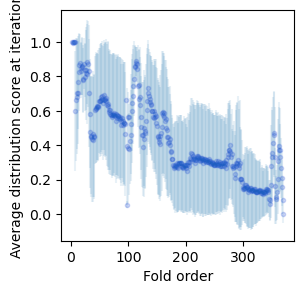

In [141]:
# std for error bar

y = list(iter2ds_mean_all_mean.values())  # average dist score
x = list(iter2ds_mean_all_mean.keys())  # iteration number
y_err = list(iter2ds_mean_all_std.values())  # variability 

# print Spearman correlation coeff.
corr, p = spearmanr(x, y)
print(f'folditer vs. average ds at iteration:')
print(f'p_value = {p}, corr = {corr}')

# Create a scatterplot with error bars
plt.figure(figsize=(3, 3))
plt.errorbar(x, y, yerr=y_err, fmt='.', alpha=0.1)  # errorbar + data points
plt.scatter(x, y, marker='.', color='b', alpha = 0.1, zorder=2)  # data points (overlay to increase alpha)
plt.ylabel('Average distribution score at iteration')
plt.xlabel('Fold order')
# plt.savefig('iterVSds_range_std_error.png', dpi=300, bbox_inches = 'tight')
plt.show()

folditer vs. average ds at iteration:
p_value = 1.027202768310673e-108, corr = -0.8589382445173462


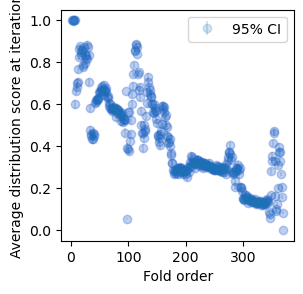

In [143]:
# do 95% CI instead (within 1.96 STE of the mean); not std, so same as if you did STE

from scipy.stats import t, spearmanr

y = list(iter2ds_mean_all_mean.values())  # average dist score
x = list(iter2ds_mean_all_mean.keys())  # iteration number
std_dev = list(iter2ds_mean_all_std.values())  # standard deviation
n = 1000  # Example: replace with actual sample sizes

# Calculate the 95% confidence interval
sem = np.array(std_dev) / np.sqrt(n)
t_critical = t.ppf(0.975, df=n-1)  # Two-tailed, 95% CI
y_err = t_critical * sem

# Print Spearman correlation coefficient
corr, p = spearmanr(x, y)
print(f'folditer vs. average ds at iteration:')
print(f'p_value = {p}, corr = {corr}')

# Create a scatterplot with error bars
plt.figure(figsize=(3, 3))
plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2, label='95% CI')
plt.scatter(x, y, marker='o', color='b', alpha=0.1, zorder=2)
plt.ylabel('Average distribution score at iteration')
plt.xlabel('Fold order')
plt.legend()
plt.show()

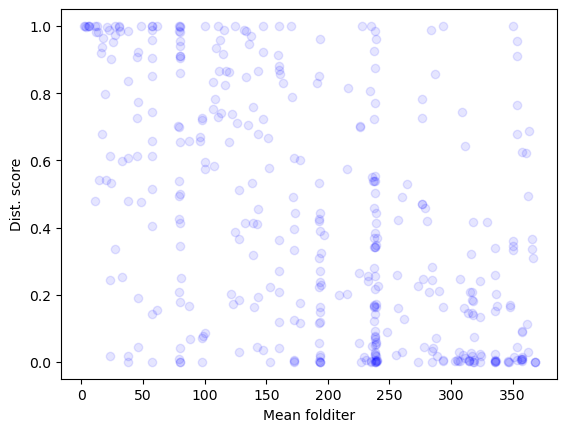

In [59]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

scatter(x2foMean, x2ds, 'Mean folditer', 'Dist. score')

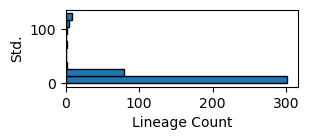

In [166]:
data1 = list(x2foStd.values())
plt.figure(figsize=(3, 1))
plt.hist(data1, bins=10, edgecolor='k', orientation='horizontal')
plt.ylabel('Std.')
plt.xlabel('Lineage Count')

# plt.yscale('log', nonpositive='clip')
# plt.savefig('inset.svg', dpi=300, bbox_inches = 'tight')

plt.show()

### adjust for oscillation

In [149]:
lengths = set()
for run in df_folds_folditer.columns:
    lengths.add(max(df_folds_folditer[run]))
lengths

{366, 367, 368, 369, 370}

folditer vs. average ds at iteration:
p_value = 1.7163196688057583e-90, corr = -0.8212795683660353


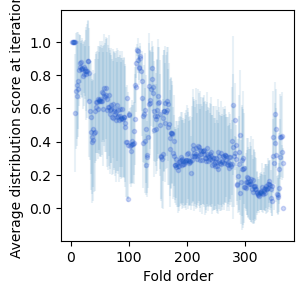

In [151]:
run2iter2ds = {}

for run in df_folds_folditer.columns:
    iter2ds = {}
    for x, i in df_folds_folditer[run].items():
        if x not in ['fold_independent', 'spontaneous']:
            if i not in iter2ds:
                iter2ds[i] = [x2ds[x]]
            else:
                iter2ds[i].append(x2ds[x])
    iter2ds_mean = {k:np.mean(v) for k,v in iter2ds.items()}
    
    if max(df_folds_folditer[run]) == 366:  # check length
        run2iter2ds[run] = iter2ds_mean


iter2ds_mean_all = {}
for run, iter2ds in run2iter2ds.items():
    for i, ds in iter2ds.items():
        if i not in iter2ds_mean_all:
            iter2ds_mean_all[i] = [ds]
        else:
            iter2ds_mean_all[i].append(ds)
            
# take average over 1000 runs
iter2ds_mean_all_mean = {k:np.mean(v) for k,v in iter2ds_mean_all.items()}
iter2ds_mean_all_std = {k:np.std(v) for k,v in iter2ds_mean_all.items()}


# plot
y = list(iter2ds_mean_all_mean.values())  # average dist score
x = list(iter2ds_mean_all_mean.keys())  # iteration number
y_err = list(iter2ds_mean_all_std.values())  # variability 

# print Spearman correlation coeff.
corr, p = spearmanr(x, y)
print(f'folditer vs. average ds at iteration:')
print(f'p_value = {p}, corr = {corr}')

# Create a scatterplot with error bars
plt.figure(figsize=(3, 3))
plt.errorbar(x, y, yerr=y_err, fmt='.', alpha=0.1)  # errorbar + data points
plt.scatter(x, y, marker='.', color='b', alpha = 0.1, zorder=2)  # data points (overlay to increase alpha)
plt.ylabel('Average distribution score at iteration')
plt.xlabel('Fold order')
# plt.savefig('iterVSds_range_std_error.png', dpi=300, bbox_inches = 'tight')
plt.show()

# old data

In [4]:
def my_func(df, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, for each iteration, map xgroups to dist scores
    for run in runs: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # within each iteration, take average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds from 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average of dist. scores across 1000 runs
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    
    print(title)
    print('average distribution score at iteration vs. iteration number')
    
    corr, p = spearmanr(x, y)
    print(f'spearman corr = {corr}, p_value = {p}')
    
    corr, p = pearsonr(x, y)
    print(f'pearson corr = {corr}, p_value = {p}')
    
    plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
    plt.ylabel('Average distribution score at iteration')
    plt.xlabel('Fold order')
    # plt.savefig(f'iterVSds_{label}.png')
    plt.show()

In [167]:
# original ne results with all pre-expansions
ne_path = '../data/fold_orders_csvs/fold_iters_pre_expansion.csv' 

In [168]:
# parse fold_iters
with open(ne_path, 'r') as file:
    lines = file.readlines()

data = []  # 10,000 * 397
labels = []  # 10,000
colnames = list(lines[0].strip().split(','))[3:-3]  # 397

lines = lines[1:]
for line in lines:
    if line[0] == ',':
        continue
    fo = line.split(',')[3:-3]
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    data.append(fo)
    labels.append(pre)
np.array(data)
df = pd.DataFrame(data, index=labels)
df.columns = colnames

In [169]:
df.head()

,2002,1,2487,2006,2003,246,7525,218,2007,304,...,4025,4024,4046,3281,3843,3456,3579,4035,4054,4036
NONE,2,3,4,5,6,7,8,9,10,11,...,362,363,364,365,366,366,367,368,368,368
NONE,2,3,4,5,6,7,13,15,16,8,...,362,361,361,364,366,366,367,368,368,368
C00016,2,6,42,4,3,16,23,33,5,9,...,364,365,366,367,371,371,372,373,373,373
C00010,2,7,38,4,3,16,23,32,5,9,...,365,365,366,368,370,370,371,374,374,374
C00010,2,7,44,4,3,16,23,32,5,9,...,364,364,367,366,371,371,372,373,373,373


# use xgroup2ds to retrieve distribution scores

In [170]:
runs = {'NONE': [], 'C00016': [], 'C00010': [], 'C00019': [], 'Z00009': [], 'ALL': [], 'C00002': [], 'Z00035': [], 'Z00047': [], 'C00004': []}
for label, row in df.iterrows():  # 1000 runs * 10 labels
    iteration2xgroup = {}
    for x, iter_num in row.items():
        if iter_num not in iteration2xgroup:
            iteration2xgroup[str(iter_num)] = [x]
        else:
            iteration2xgroup[str(iter_num)].append(x)
    runs[label].append(iteration2xgroup)

In [11]:
len(runs['NONE'])

1000

# function to draw scatterplot

In [17]:
def my_func(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, for each iteration, map xgroups to dist scores
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # within each iteration, take average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds from 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average of dist. scores across 1000 runs
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    
    print(title)
    print('average distribution score at iteration vs. iteration number')
    
    corr, p = spearmanr(x, y)
    print(f'spearman corr = {corr}, p_value = {p}')
    
    corr, p = pearsonr(x, y)
    print(f'pearson corr = {corr}, p_value = {p}')
    
    plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'iteration number ({label})')
    # plt.savefig(f'iterVSds_{label}.png')
    plt.show()

In [13]:
runs.keys()

dict_keys(['NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'])

arc + bac
average distribution score at iteration vs. iteration number
spearman corr = -0.861642023028738, p_value = 1.943825793690615e-110
pearson corr = -0.8613149801868598, p_value = 2.907006094163287e-110


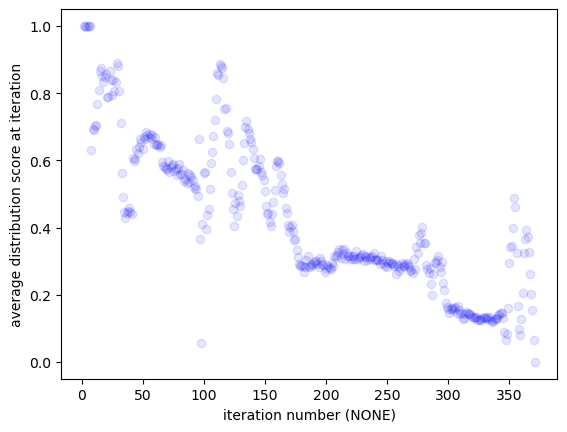

In [18]:
my_func('NONE', xgroup2ds_ab, 'arc + bac')
# my_func('C00002', xgroup2ds_ab, 'arc + bac')
# my_func('C00004', xgroup2ds_ab, 'arc + bac')
# my_func('C00010', xgroup2ds_ab, 'arc + bac')
# my_func('C00016', xgroup2ds_ab, 'arc + bac')
# my_func('C00019', xgroup2ds_ab, 'arc + bac')
# my_func('Z00009', xgroup2ds_ab, 'arc + bac')
# my_func('Z00035', xgroup2ds_ab, 'arc + bac')
# my_func('Z00047', xgroup2ds_ab, 'arc + bac')
# my_func('ALL', xgroup2ds_ab, 'arc + bac')

In [19]:
# show errorbar for y-axis

def my_func_range(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, map iteration to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # take run-wise average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average across 1000 runs
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean
        
    iterations_std = {}
    for i in iterations.keys():
        iterations_std[i] = np.std(iterations[i])  # std.
        # iterations_std[i] = np.std(iterations[i]) / np.sqrt(np.size(iterations[i]))  # std. error
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    y_err = list(iterations_std.values())  # variability 

    # Create a scatterplot with error bars
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2)
    corr, p = spearmanr(x, y)
    print(title)
    print(f'iteration number vs. average distribution score at iteration: corr = {corr}, p_value = {p}')
    plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
    plt.ylabel('Average distribution score at iteration')
    plt.xlabel('Fold order')
    # plt.savefig(f'iterVSds_range_std_error.png', dpi=300, bbox_inches = 'tight')
    plt.show()

arc + bac
iteration number vs. average distribution score at iteration: corr = -0.861642023028738, p_value = 1.943825793690615e-110


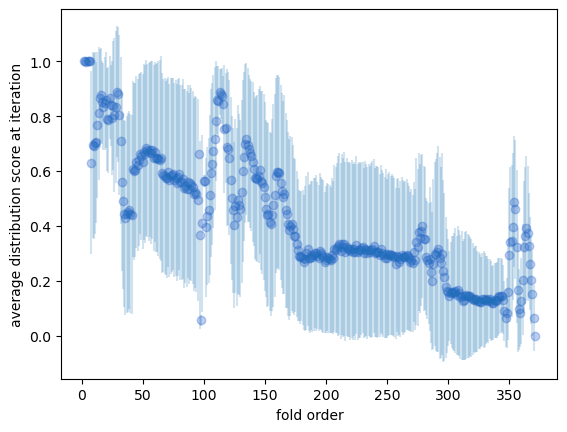

In [20]:
my_func_range('NONE', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00002', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00004', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00010', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00016', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00019', xgroup2ds_ab, 'arc + bac')
# my_func_range('Z00009', xgroup2ds_ab, 'arc + bac')
# my_func_range('Z00035', xgroup2ds_ab, 'arc + bac')
# my_func_range('Z00047', xgroup2ds_ab, 'arc + bac')
# my_func_range('ALL', xgroup2ds_ab, 'arc + bac')

In [174]:
def my_func_line(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, map iteration to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # take run-wise average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]

#     print(iterations.keys())  # fold order [2-371]
    print(len(iterations.keys()))
    print([len(iterations[key]) for key in iterations.keys()])  # last 3 iternums don't always exist...
    
    
# Create 1000 line plots 
    plt.figure(figsize=(50, 10))
    colors = ['#0051ff', '#00ff04', 'black', '#ff8d00', '#ff1a00']
    
    for i in range(2, 3):
        plt.scatter(list(iterations.keys())[:-3], [iterations[key][i] for key in list(iterations.keys())[:-3]] , color=colors[i], alpha = 0.5, zorder=2)

    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'fold order')
    plt.xticks([0, 98, 198, 298, 358])
    plt.xlim([2, 365])
    # plt.savefig(f'iterVSds_line_3.png', dpi=300, bbox_inches = 'tight')
    plt.show()

370
[1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000,

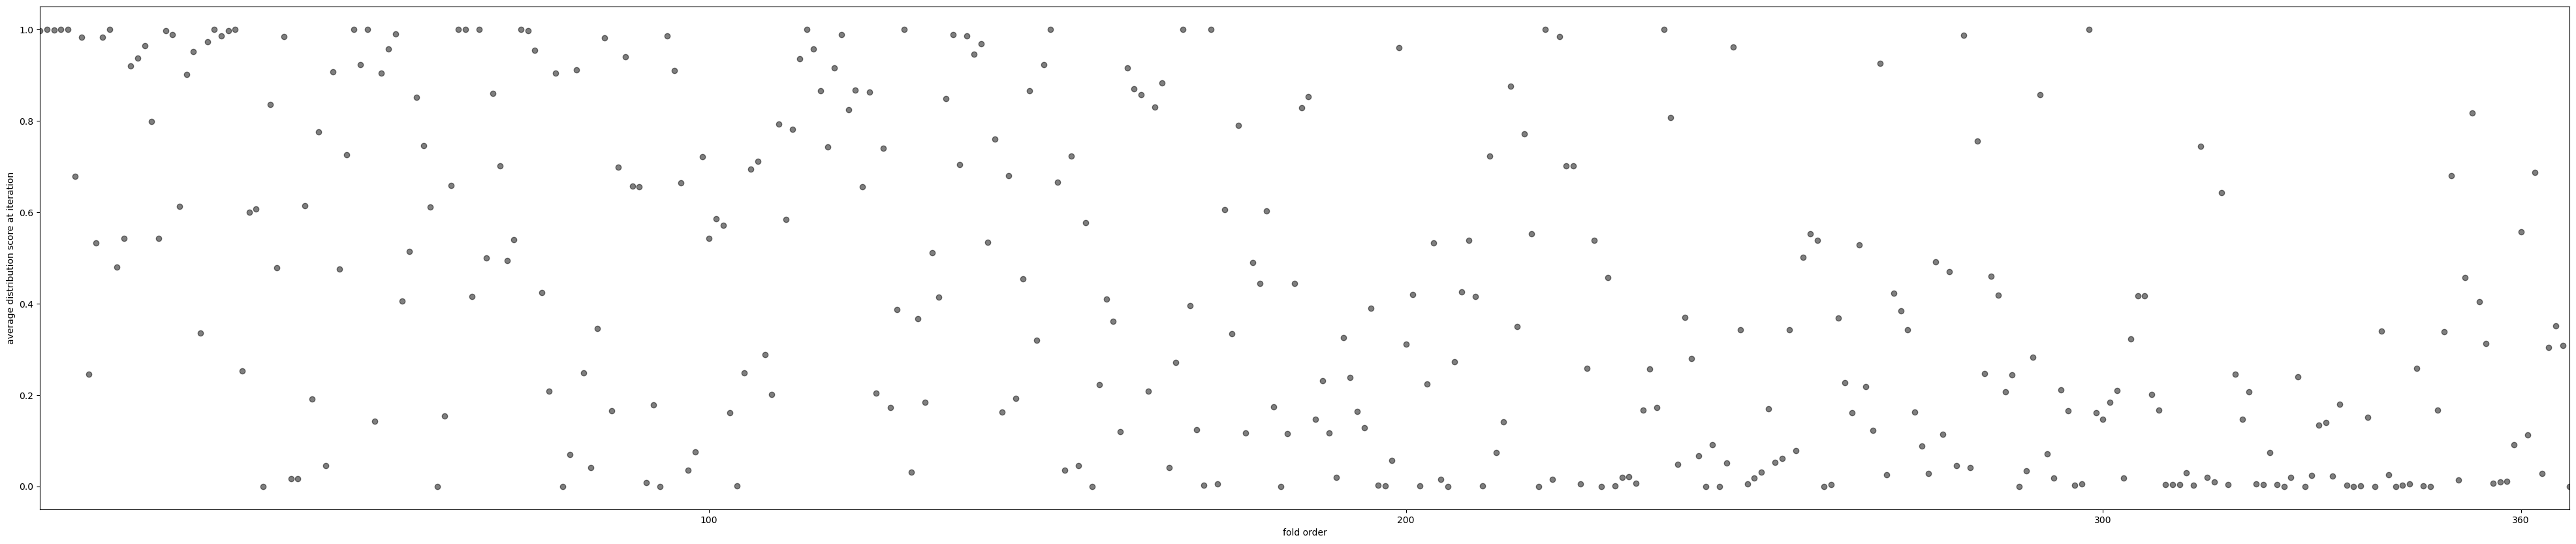

In [175]:
my_func_line('NONE', x2ds, 'arc + bac')

In [22]:
# show error bar for scatterplot WITH THE SAME #FOLDITER

def my_func_range_same_folditer(label, xgroup2ds, title, num_folditer):
    runs_ds = []  # len=1,000*370ish; [{iter:[ds]}, {iter:[ds, ds]}, ...]
    # map xgroup to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # sometimes, 2-3 folds are injected in the same iteration
    # take iteration-wise average of dist scores {iter:[ds, ds]} => {iter:[ds_average]}
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across RUNS WITH THE SAME #FOLDITER
    runs_ds_ave_folditer = []
    for run in runs_ds_ave:
        if len(run.keys()) == num_folditer:
            runs_ds_ave_folditer.append(run)
    print(f'len(runs_ds_ave_folditer)={len(runs_ds_ave_folditer)}')
    
    iterations = {key: [] for key in runs_ds_ave_folditer[0]}
    for run in runs_ds_ave_folditer:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average across RUNS WITH THE SAME #FOLDITER
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean
        
    iterations_std = {}
    for i in iterations.keys():
        iterations_std[i] = np.std(iterations[i])  # std.
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    y_err = list(iterations_std.values())  # variability

    # Create a scatterplot with error bars
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2)
    corr, p = spearmanr(x, y)
    print(title)
    print(f'iteration number vs. average distribution score at iteration: corr = {corr}, p_value = {p}')
    plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'fold order ({num_folditer})')
    # plt.savefig(f'iterVSds_range_std_{num_folditer}.png', dpi=300, bbox_inches = 'tight')
    plt.show()

len(runs_ds_ave_folditer)=100
arc + bac
iteration number vs. average distribution score at iteration: corr = -0.8327177186683737, p_value = 1.667561216020597e-96


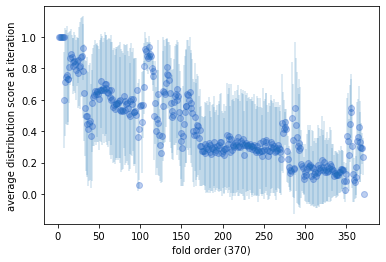

In [23]:
my_func_range_same_folditer('NONE', xgroup2ds_ab, 'arc + bac', 370)

# check average fold_order given xgroup

In [24]:
def x2aveFO(xgroup, label):
    fo_list = []
    for run in runs[label]: 
        for iteration in run.keys():          
            for x in run[iteration]:
                if x == xgroup:
                    fo_list.append(int(iteration))
    return [sum(fo_list) / len(fo_list), np.std(fo_list)]

In [25]:
x2aveFO('2003', 'NONE')

[6.511, 0.4998789853554558]

In [26]:
x2aveFO('3997', 'NONE')

[304.303, 5.128273686144296]

In [27]:
x2aveFO('3997', 'ALL')

[305.351, 20.484428207787495]

In [31]:
x2foMeanStdNONE = {}
for x in xgroup_keys:
    x2foMeanStdNONE[x] = x2aveFO(x, 'NONE')

In [32]:
# dict2csv(x2foMeanStdNONE, 'x2foMeanStdNONE.csv')

In [28]:
# let's only take the mean, and save them as csv
x2foAveNONE = {}
for x in xgroup_keys:
    x2foAveNONE[x] = x2aveFO(x, 'NONE')[0]

x2foAveALL = {}
for x in xgroup_keys:
    x2foAveALL[x] = x2aveFO(x, 'ALL')[0]
    
# dict2csv(x2foAveNONE, 'x2foAveNONE.csv')
# dict2csv(x2foAveALL, 'x2foAveALL.csv')

In [29]:
# keep this for analysis of mean, std
x2aveFO('602', 'NONE'), x2aveFO('4952', 'NONE'), x2aveFO('4953', 'NONE')

([106.619, 2.946156648924154],
 [106.619, 2.946156648924154],
 [107.619, 2.946156648924154])

# annotate group1 folds

In [ ]:
first10 = {'325', '2002', '218', '206', '4953', '2003', '2007', '602', '2005', '4952'}
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}

In [ ]:
for x in group1:
    print(x, xgroup2ds_ab[x], x2aveFO(x, 'NONE'))

In [ ]:
group1_ds = []
group1_fo = []
for x in group1 - first10:
    group1_ds.append(xgroup2ds_ab[x])
    group1_fo.append(x2foAveNONE[x])
    
first10_ds = []
first10_fo = []
for x in first10:
    first10_ds.append(xgroup2ds_ab[x])
    first10_fo.append(x2foAveNONE[x])

In [ ]:
# annotate group1

def my_func_red(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, map iteration to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # take run-wise average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average across 1000 runs
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean
        
    iterations_std = {}
    for i in iterations.keys():
        iterations_std[i] = np.std(iterations[i])  # std.
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    y_err = list(iterations_std.values())  # variability (standard deviation in this case)
    
    # blue = group1
    x_blue = group1_fo
    y_blue = group1_ds
    
    # gray = first10
    x_gray = first10_fo
    y_gray = first10_ds

    # Create a scatterplot with error bars
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2, color='red')
    corr, p = spearmanr(x, y)
    print(title)
    print(f'iteration number vs. average distribution score at iteration: corr = {corr}, p_value = {p}')
    plt.scatter(x, y, marker='o', color='red', alpha = 0.1, zorder=2)
    plt.scatter(x_blue, y_blue, marker='o', color='blue', alpha = 0.5, zorder=2)
    plt.scatter(x_gray, y_gray, marker='o', color='gray', alpha = 1, zorder=2)
    
    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'iteration number ({label})')
    # plt.savefig(f'iterVSds_{label}_range.png')
    plt.show()

In [ ]:
my_func_red('NONE', xgroup2ds_ab, 'arc + bac')

In [ ]:
my_func_red('NONE', xgroup2ds_ab, 'arc + bac')
my_func_red('NONE', xgroup2ds_e, 'euk')

In [ ]:
for x in first10:
    print(x, xgroup2ds_ab[x], x2aveFO(x, 'NONE'))

# check some folds

In [ ]:
label = 'ALL'
title = 'arc + bac'

runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]

# for each run, map iteration to dist score
for run in runs[label]: 
    iteration2ds = {}
    for iteration in run.keys():
        ds_list = []
        for xgroup in run[iteration]:
            ds_list.append(xgroup2ds_ab[xgroup])
        iteration2ds[iteration] = ds_list
    runs_ds.append(iteration2ds)

# take run-wise average of dist scores (some iteration injects 2+ folds)
runs_ds_ave = []
for run in runs_ds:
    iteration2ds_ave = {}
    for iteration in run.keys():
        iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
    runs_ds_ave.append(iteration2ds_ave)

# accumulate iteration2average_ds across 1000 runs
iterations = {key: [] for key in runs_ds_ave[0]}
for run in runs_ds_ave:
    for key in run.keys():
        if key in iterations.keys():
            iterations[key].append(run[key])
        else:
            iterations[key] = [run[key]]

# take iteration-wise average across 1000 runs
iterations_ave = {}
for i in iterations.keys():
    iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean

In [ ]:
for key, value in iterations_ave.items():
    print(key, value)

## dip at iter# = 98 (NONE)

In [ ]:
iter98 = []
for run in runs['NONE']:
    iter98.append(run['98'])
iter98

In [ ]:
x_set = set()
for injection in iter98:
    for x in injection:
        x_set.add(x)
print(x_set)

In [ ]:
# X108 |ds_a/b/e= 0.08 0.07 1.0 |fo=98.5 |ns=4294 |#rxn=59 |group2 |indep |Xname=EF-hand
# X4178 |ds_a/b/e= 0.02 0.12 0.92 |fo=97.5 |ns=4315 |#rxn=21 |group2 |aux |Xname=N/A
# X355 |ds_a/b/e= 0.0 0.0 0.38 |fo=97.5 |ns=4315 |#rxn=19 |group2 |aux |Xname=N/A

## dips at bottom left (ALL)

In [ ]:
bl = []
for iterNum, aveDS in iterations_ave.items():
    if aveDS < 0.5 and int(iterNum) < 80:
        print(iterNum, aveDS)
        bl.append(iterNum)

In [ ]:
for iterNum in bl:
    print(iterNum)
    for run in runs['ALL']:
        print(run[iterNum])
# note that it's always a single-fold injection

In [ ]:
bottomLeft = {'76': [],
 '25': [],
 '7': [],
 '77': [],
 '39': [],
 '30': [],
 '75': [],
 '62': []}

for iterNum in bl:
    for run in runs['ALL']:
        bottomLeft[iterNum].append(run[iterNum][0])

for key in bottomLeft.keys():
    bottomLeft[key] = set(bottomLeft[key])
bottomLeft

In [ ]:
x_set2 = set()
for key in bottomLeft.keys():
    for x in bottomLeft[key]:
        x_set2.add(x)

In [ ]:
x_set2

# checking why runs have different folditer sizes

In [ ]:
['144', '3374']

In [ ]:
print(len(runs['NONE'][2].keys()))
print(len(runs['NONE'][0].keys()))
print(len(runs['NONE'][5].keys()))
print(len(runs['NONE'][4].keys()))
print(len(runs['NONE'][15].keys()))

In [ ]:
multiple366 = {}
count = 0
for key, values in runs['NONE'][2].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        multiple366[key] = values
        count += 1
print(count)

In [ ]:
multiple367 = {}
count = 0
for key, values in runs['NONE'][0].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        multiple367[key] = values
        count += 1
print(count)

In [ ]:
multiple368 = {}
count = 0
for key, values in runs['NONE'][5].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        multiple368[key] = values
        count += 1
print(count)

# 102: ['7586', '4044']

In [ ]:
multiple369 = {}
count = 0
for key, values in runs['NONE'][4].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        count += 1
        multiple369[key] = values
print(count)

# 102 ['4019', '223']

In [ ]:
multiple370 = {}
count = 0
for key, values in runs['NONE'][15].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        count += 1
        multiple370[key] = values
print(count)

In [ ]:
multiples = {}
dicts = [multiple366, multiple367, multiple368, multiple369, multiple370]
for d in dicts:
    for value in d.values():
        if frozenset(value) not in multiples.keys():
            multiples[frozenset(value)] = 1
        else:
            multiples[frozenset(value)] += 1

In [ ]:
multiples